<a href="https://colab.research.google.com/github/r0gandhi15/CS4372_HW2/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2: Machine Learning Using Trees

## Julianna Dino

NetID: jgd220003

## Roma Gandhi

NetID: rxg220067

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import graphviz
import multiprocessing

!pip install xgboost
import xgboost as xgb

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# 2.1 Pre-Processing

In [2]:
#load in data
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets
y_G3 = student_performance.data.targets['G3']
df = pd.concat([X, y], axis=1)


In [3]:
y.head(10)

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13
5,12,12,13
6,13,12,13
7,10,13,13
8,15,16,17
9,12,12,13


In [4]:
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   G1      649 non-null    int64
 1   G2      649 non-null    int64
 2   G3      649 non-null    int64
dtypes: int64(3)
memory usage: 15.3 KB
None


In [5]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [6]:
pd.set_option('display.max_columns', None)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [22]:
y = y_G3
X = pd.get_dummies(df, drop_first=True)
X = X.drop('G3', axis=1)

# Create a binary target variable: 1 for pass (G3 >= 10), 0 for fail (G3 < 10)
y_binary = (y >= 10).astype(int)

print(X.info())
print('\nBinary target variable (y_binary) value counts:\n', y_binary.value_counts())
print('\nBinary target variable (y_binary) head:\n', y_binary.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                649 non-null    int64
 1   Medu               649 non-null    int64
 2   Fedu               649 non-null    int64
 3   traveltime         649 non-null    int64
 4   studytime          649 non-null    int64
 5   failures           649 non-null    int64
 6   famrel             649 non-null    int64
 7   freetime           649 non-null    int64
 8   goout              649 non-null    int64
 9   Dalc               649 non-null    int64
 10  Walc               649 non-null    int64
 11  health             649 non-null    int64
 12  absences           649 non-null    int64
 13  G1                 649 non-null    int64
 14  G2                 649 non-null    int64
 15  school_MS          649 non-null    bool 
 16  sex_M              649 non-null    bool 
 17  address_U       

In [32]:
# Create a binary target variable: 1 for pass (G3 >= 10), 0 for fail (G3 < 10)
y_binary = (y >= 10).astype(int)

print(y_binary.value_counts())
print(y_binary.head())

G3
1    549
0    100
Name: count, dtype: int64
0    1
1    1
2    1
3    1
4    1
Name: G3, dtype: int64


# 2.2 Model Construction & 2.3 Visualization

### Plain Decision Tree Classifier

In [ ]:
## REPLACE * WITH TRUE VALUES (DELETE THIS WHEN DONE) ##

In [24]:
X_train, X_test, y_binary_train, y_binary_test = train_test_split(X, y_binary, test_size=0.3, random_state=1) # 70% training and 30% test

In [29]:
#PARAMETER TUNING
from sklearn.model_selection import GridSearchCV
dt_pipe = Pipeline([('mms', MinMaxScaler()), ('dt', DecisionTreeClassifier())])
params = [{'dt__max_depth': [3, 5, 7, 9],
           'dt__min_samples_leaf'
           : [2, 3, 5]}]

gs_dt = GridSearchCV(dt_pipe, param_grid=params,scoring='accuracy', cv = 5)
gs_dt.fit(X_train, y_binary_train)

print(gs_dt.best_params_)
print(gs_dt.score(X_test, y_binary_test))

{'dt__max_depth': 3, 'dt__min_samples_leaf': 3}
0.9230769230769231


In [37]:
#FITTING THE MODEL
clf = DecisionTreeClassifier(max_depth = 3, random_state = 2)
clf.fit(X_train, y_binary_train)

y_pred = clf.predict(X_test)
predicted_probas = clf.predict_proba(X_test)

In [35]:
#CLASSIFICATION REPORT
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_binary_test, y_pred)) # predictions contain predicted values (derived from probability with 0.5 threshold)
print('Predicted labels: ', y_pred)
print('Accuracy: ', accuracy_score(y_binary_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.63      0.69        30
           1       0.94      0.96      0.95       165

    accuracy                           0.91       195
   macro avg       0.85      0.80      0.82       195
weighted avg       0.91      0.91      0.91       195

Predicted labels:  [0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1]
Accuracy:  0.9128205128205128


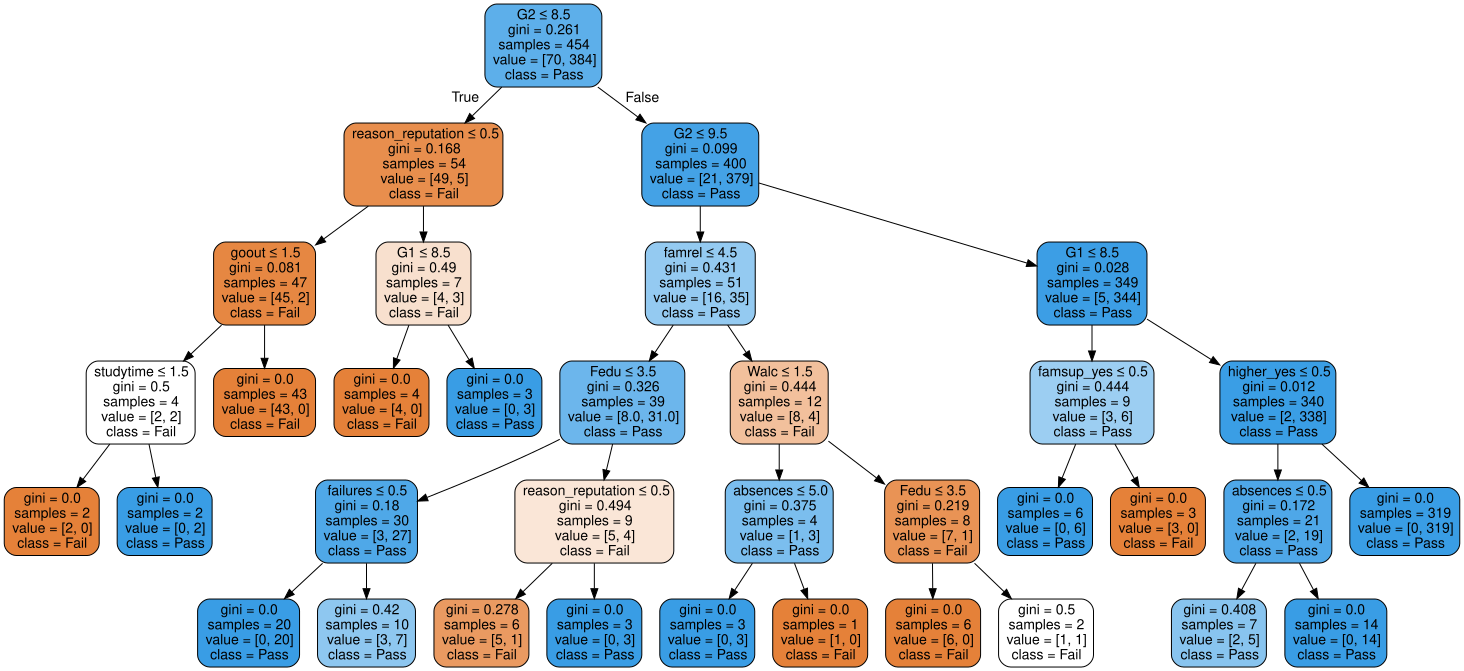

In [36]:
#TREE VISUALIZATION
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names = X.columns,class_names=['Fail', 'Pass'],
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

### Random Forest Classifier

In [33]:
rf = RandomForestClassifier()

#PARAMETER TUNING
params = {'max_depth': [5, 7, 9],
          'n_estimators': [50, 100, 200],
          'max_features': ['sqrt', 'log2']
          }

grid = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(X, y_binary)

print(grid.best_params_)
# find best model score
print(grid.score(X_test, y_binary_test))

{'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}
0.9487179487179487


In [38]:
#RANDOM FOREST MODEL
rf = RandomForestClassifier(max_depth=grid.best_params_['max_depth'],
                            n_estimators=grid.best_params_['n_estimators'],
                            max_features=grid.best_params_['max_features'],
                            random_state=1)
rf.fit(X_train, y_binary_train)
y_pred = rf.predict(X_test)
print("-------------------Random Forest Model Report------------------------")

print("accuracy = " + str(accuracy_score(y_binary_test, y_pred)))
print(classification_report(y_binary_test,y_pred))

-------------------Random Forest Model Report------------------------
accuracy = 0.9230769230769231
              precision    recall  f1-score   support

           0       0.94      0.53      0.68        30
           1       0.92      0.99      0.96       165

    accuracy                           0.92       195
   macro avg       0.93      0.76      0.82       195
weighted avg       0.92      0.92      0.91       195



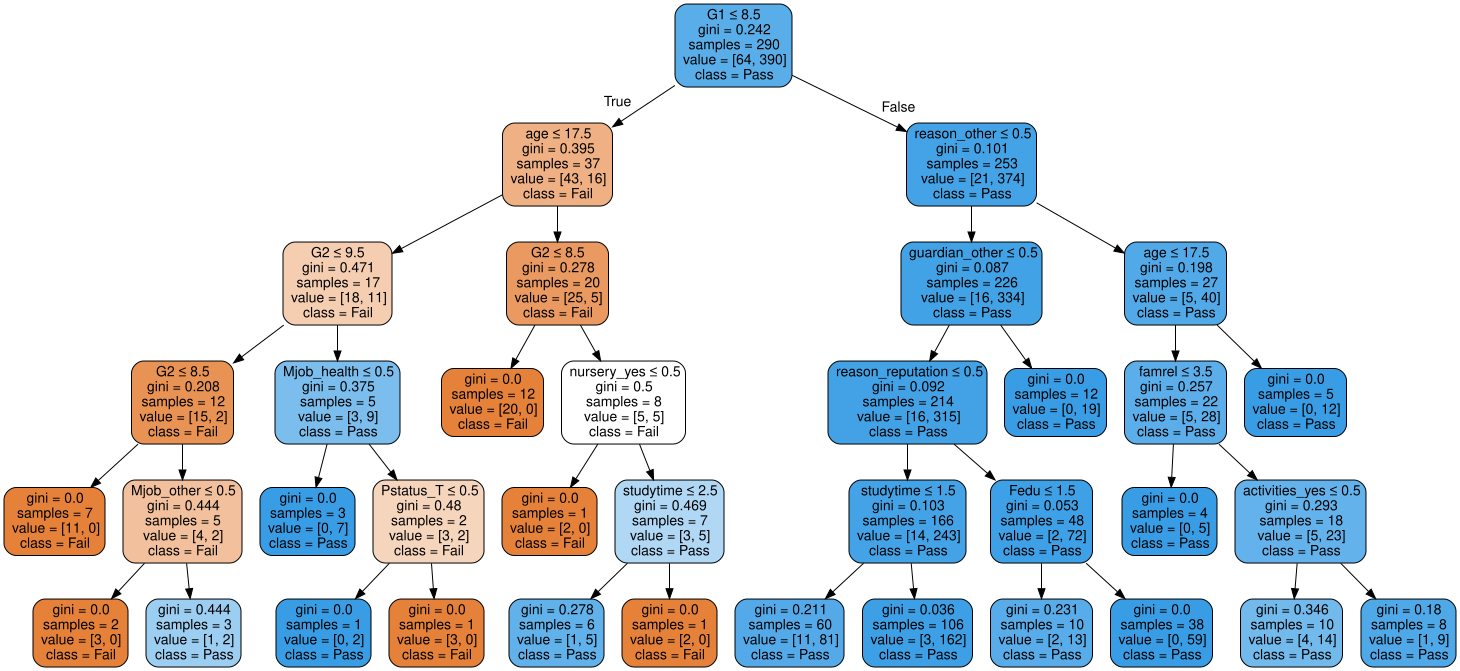

In [39]:
#TREE VISUALIZATION
estimator = rf.estimators_[0]

dot_data_rf = tree.export_graphviz(estimator, out_file=None,
                         feature_names=X.columns,
                         class_names=['Fail', 'Pass'],
                         filled=True, rounded=True,
                         special_characters=True)
graph_rf = graphviz.Source(dot_data_rf)
graph_rf

### Adabot Classifier

In [40]:
ad = AdaBoostClassifier(random_state=1)
ad = ad.fit(X_train,y_binary_train)
#Predict the response for test dataset
y_pred = ad.predict(X_test)
print("-------------------Adaboost Model Report------------------------")

print("accuracy = " + str(accuracy_score(y_binary_test, y_pred)))
print(classification_report(y_binary_test,y_pred))

-------------------Adaboost Model Report------------------------
accuracy = 0.9230769230769231
              precision    recall  f1-score   support

           0       0.83      0.63      0.72        30
           1       0.94      0.98      0.96       165

    accuracy                           0.92       195
   macro avg       0.88      0.80      0.84       195
weighted avg       0.92      0.92      0.92       195



### XGBoost Classifier

In [41]:
xgb_model = xgb.XGBClassifier(n_jobs=multiprocessing.cpu_count() // 2, objective='binary:logistic', eval_metric='logloss')

#TUNING PARAMETERS
clf = GridSearchCV(xgb_model, {'max_depth': [2, 4, 6],
                                   'n_estimators': [50, 100, 200]}, verbose=1,
                       n_jobs=2, scoring='accuracy', cv=5)
clf.fit(X_train, y_binary_train)
print(clf.best_score_)
print(clf.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
0.936190476190476
{'max_depth': 4, 'n_estimators': 100}


In [42]:
#FITTING MODEL
model = clf.best_estimator_

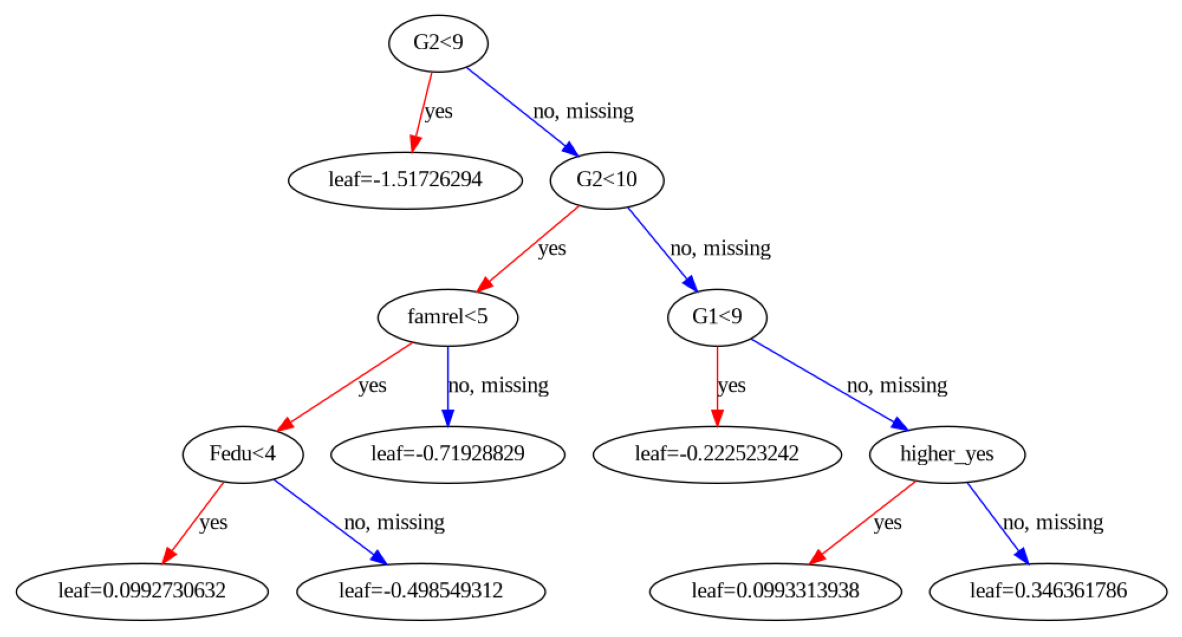

In [43]:
#TREE VISUALIZATION
fig, ax = plt.subplots(figsize=(15, 15)) # Adjust figure size as needed
xgb.plot_tree(model, tree_idx=0, ax=ax)
plt.show()

# 2.4 Result Analysis

### Decision Tree Classifier: Detailed Metrics and Plots

Confusion Matrix (Decision Tree):
 [[ 19  11]
 [  4 161]]


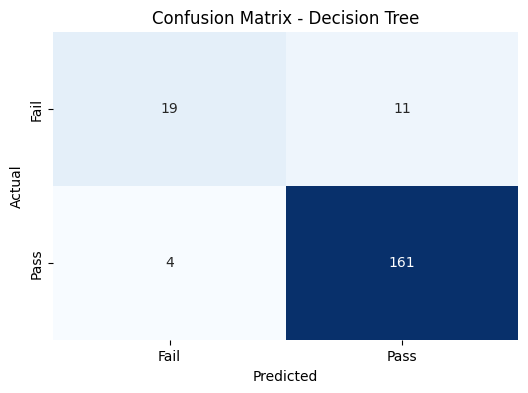

In [47]:
# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_binary_test, y_pred)
print('Confusion Matrix (Decision Tree):\n', cm_dt)

# Display using seaborn for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

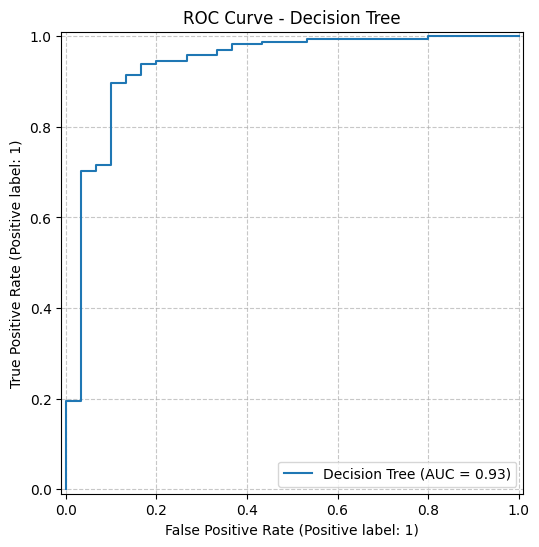

In [48]:
# ROC Curve for Decision Tree
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(clf, X_test, y_binary_test, ax=ax, name='Decision Tree')
plt.title('ROC Curve - Decision Tree')
plt.show()

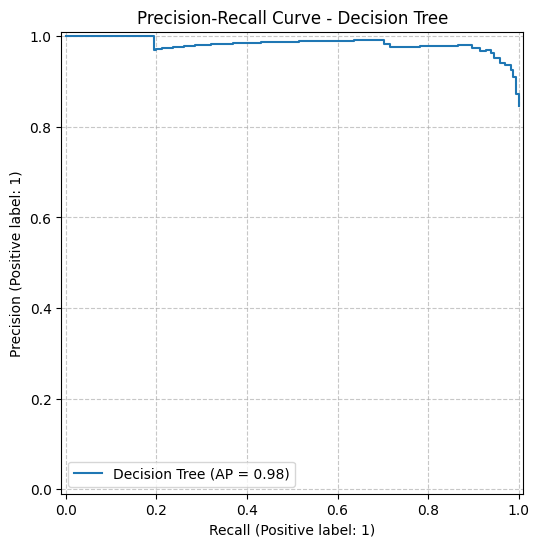

In [49]:
# Precision-Recall Curve for Decision Tree
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(clf, X_test, y_binary_test, ax=ax, name='Decision Tree')
plt.title('Precision-Recall Curve - Decision Tree')
plt.show()

### Random Forest Classifier: Detailed Metrics and Plots

Confusion Matrix (Random Forest):
 [[ 16  14]
 [  1 164]]


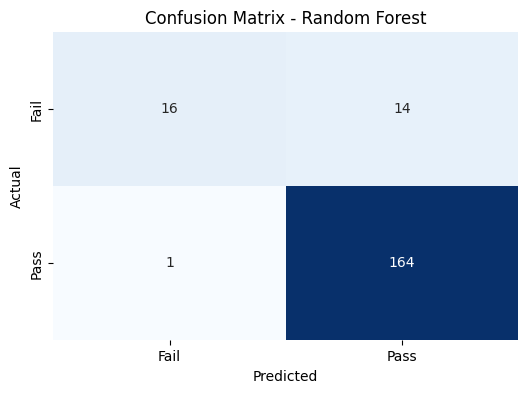

In [50]:
# Confusion Matrix for Random Forest
y_pred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_binary_test, y_pred_rf)
print('Confusion Matrix (Random Forest):\n', cm_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

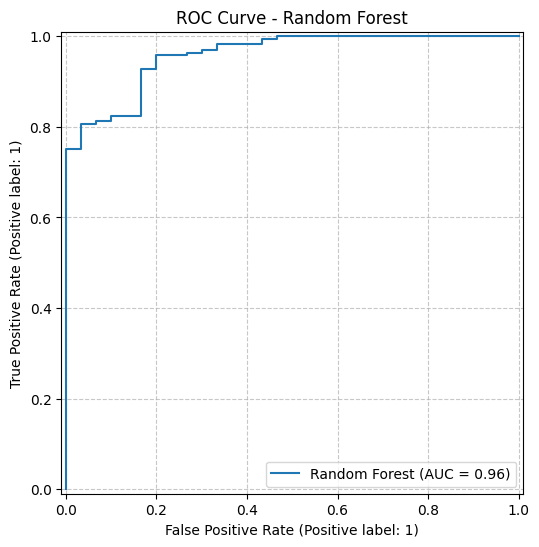

In [51]:
# ROC Curve for Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, X_test, y_binary_test, ax=ax, name='Random Forest')
plt.title('ROC Curve - Random Forest')
plt.show()

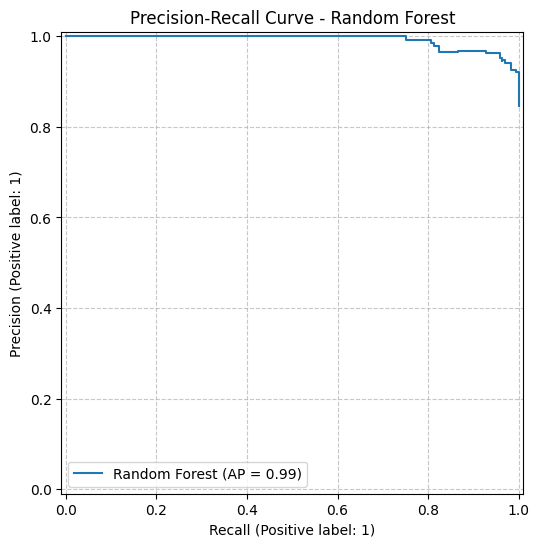

In [52]:
# Precision-Recall Curve for Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(rf, X_test, y_binary_test, ax=ax, name='Random Forest')
plt.title('Precision-Recall Curve - Random Forest')
plt.show()

### AdaBoost Classifier: Detailed Metrics and Plots

Confusion Matrix (AdaBoost):
 [[ 19  11]
 [  4 161]]


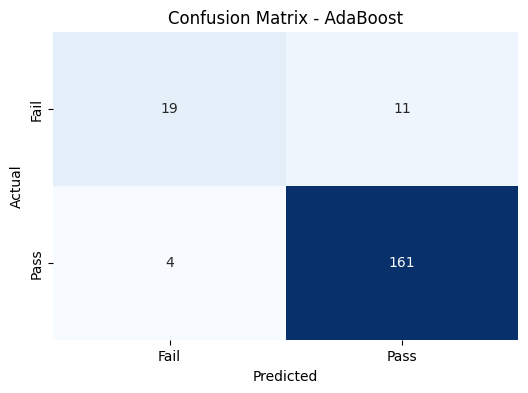

In [53]:
# Confusion Matrix for AdaBoost
y_pred_ad = ad.predict(X_test) # Re-predict for consistency
cm_ad = confusion_matrix(y_binary_test, y_pred_ad)
print('Confusion Matrix (AdaBoost):\n', cm_ad)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_ad, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AdaBoost')
plt.show()

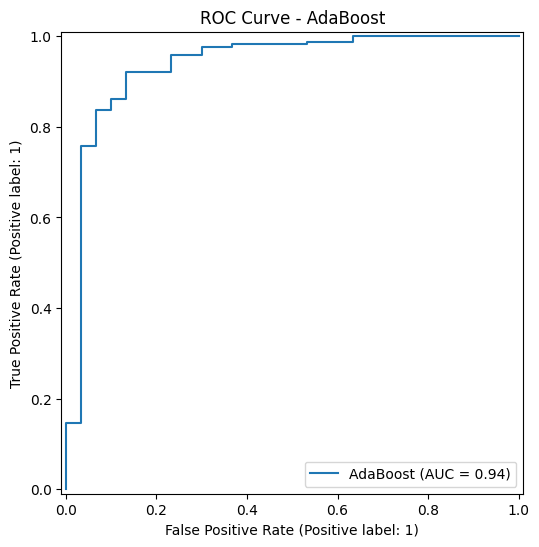

In [56]:
# ROC Curve for AdaBoost
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(ad, X_test, y_binary_test, ax=ax, name='AdaBoost')
plt.title('ROC Curve - AdaBoost')
plt.show()

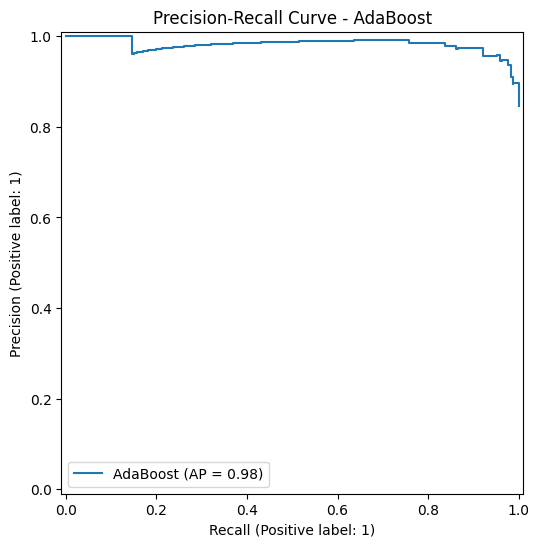

In [58]:
# Precision-Recall Curve for AdaBoost
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(ad, X_test, y_binary_test, ax=ax, name='AdaBoost')
plt.title('Precision-Recall Curve - AdaBoost')
plt.show()

### XGBoost Classifier: Detailed Metrics and Plots

Confusion Matrix (XGBoost):
 [[ 19  11]
 [  5 160]]


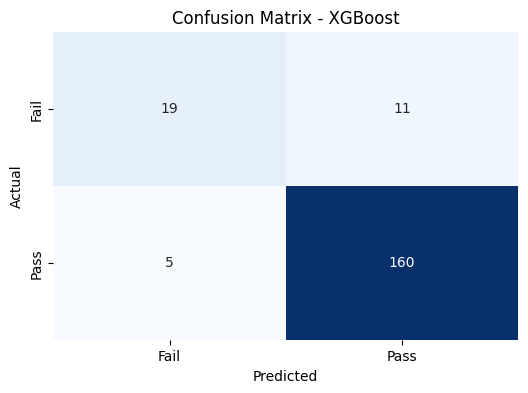

In [59]:
# Confusion Matrix for XGBoost
y_pred_xgb = model.predict(X_test) # Re-predict for consistency
cm_xgb = confusion_matrix(y_binary_test, y_pred_xgb)
print('Confusion Matrix (XGBoost):\n', cm_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

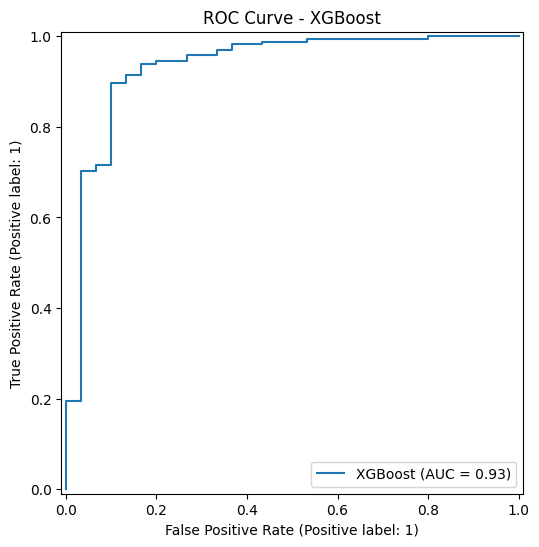

In [61]:
# ROC Curve for XGBoost
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(model, X_test, y_binary_test, ax=ax, name='XGBoost')
plt.title('ROC Curve - XGBoost')
plt.show()

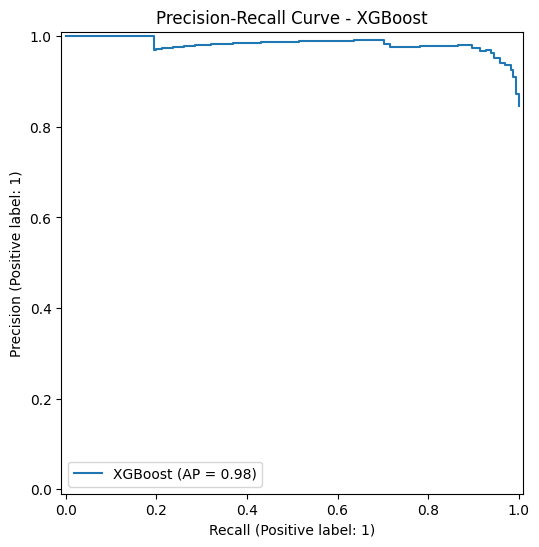

In [62]:
# Precision-Recall Curve for XGBoost
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(model, X_test, y_binary_test, ax=ax, name='XGBoost')
plt.title('Precision-Recall Curve - XGBoost')
plt.show()